In [2]:
import sys
print(sys.executable)

C:\Python314\python.exe


In [3]:
print(sys.version)

3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]


In [4]:
%pip install tensorflow

  Using cached tensorflow-2.22.0rc0-cp314-cp314-win_amd64.whl.metadata (4.6 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.5.0-cp314-cp314-win_amd64.whl.metadata (7.7 kB)
  Using cached grpcio-1.84.0-cp314-cp314-win_amd64.whl.metadata (3.9 kB)
  Using cached keras_nightly-3.16.0.dev2026100405-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.15.1-cp314-cp314-win_amd64.whl.metadata (3.1 kB)
  Using cached wheel-0.48.0-py3-none-any.whl.metadata (2.3 kB)
   ---------------------------------------- 0.0/384.1 MB ? eta -:--:-

In [5]:
import tensorflow as tf

print(tf.__version__)

2.22.0-rc0


In [7]:
from keras.models import Sequential

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [9]:
pip install yfinance --upgrade


Note: you may need to restart the kernel to use updated packages.


In [6]:

pip install --upgrade yfinance


Note: you may need to restart the kernel to use updated packages.


In [10]:
# ✅ Modern yfinance stock data fetching (no pdr_override needed)

import yfinance as yf
from datetime import datetime

# Define stock symbol and date range
symbol = "AAPL"  # Example: Apple
start = datetime(2020, 1, 1)
end = datetime(2023, 1, 1)

# Download stock data directly from Yahoo Finance
data = yf.download(symbol, start=start, end=end)

# Display first few rows
print(data.head())


[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.271538  72.331694  71.029915  71.282568  135480400
2020-01-03  71.568924  72.326889  71.345145  71.501549  146322800
2020-01-06  72.139183  72.177684  70.442784  70.693036  118387200
2020-01-07  71.799934  72.403897  71.580965  72.148835  108872000
2020-01-08  72.954895  73.255675  71.503931  71.503931  132079200


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import yfinance as yf

In [12]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import yfinance as yf

# Visualization setup
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# Define stock tickers and company names
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
company_names = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]

# Define time range
end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

# ✅ Download all stock data at once (prevents rate limit errors)
data = yf.download(tech_list, start=start, end=end, group_by='ticker', progress=False)

# ✅ Combine data for all companies
company_list = []
for stock, name in zip(tech_list, company_names):
    df_temp = data[stock].copy()
    df_temp["company_name"] = name
    company_list.append(df_temp)

# ✅ Combine all into one DataFrame
df = pd.concat(company_list)
df.index = pd.to_datetime(df.index)

# ✅ Filter only Amazon data (like your table)
df_amazon = df[df['company_name'] == 'AMAZON']

# ✅ Display output similar to your sample
print(df_amazon.head(10))


Price             Open        High         Low       Close    Volume  \
Date                                                                   
2025-10-06  221.000000  221.729996  216.029999  220.899994  43690900   
2025-10-07  220.880005  222.889999  220.169998  221.779999  31194700   
2025-10-08  222.919998  226.729996  221.190002  225.220001  46686000   
2025-10-09  225.000000  228.210007  221.750000  227.740005  46412100   
2025-10-10  226.210007  228.250000  216.000000  216.369995  72367500   
2025-10-13  217.699997  220.679993  217.039993  220.070007  37809700   
2025-10-14  215.559998  219.320007  212.600006  216.389999  45665600   
2025-10-15  216.619995  217.710007  212.660004  215.570007  45909500   
2025-10-16  215.669998  218.589996  212.809998  214.470001  42414600   
2025-10-17  214.559998  214.800003  211.029999  213.039993  45986900   

Price      company_name  
Date                     
2025-10-06       AMAZON  
2025-10-07       AMAZON  
2025-10-08       AMAZON  
2025-

In [13]:
# Import required libraries
import pandas as pd
import yfinance as yf
from datetime import datetime

# Define stock symbol and time range
symbol = 'AAPL'
end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

# ✅ Download Apple stock data directly
AAPL = yf.download(symbol, start=start, end=end)

# ✅ Display summary statistics
print(AAPL.describe())


[*********************100%***********************]  1 of 1 completed

Price        Close        High         Low        Open        Volume
Ticker        AAPL        AAPL        AAPL        AAPL          AAPL
count   250.000000  250.000000  250.000000  250.000000  2.500000e+02
mean    284.503801  287.398600  281.419038  284.229917  4.819137e+07
std      27.094437   27.265193   26.607390   26.746527  2.149777e+07
min     244.367310  247.934151  242.759224  245.692432  1.791060e+07
25%     261.815353  264.506963  259.091903  261.578285  3.751968e+07
50%     274.707855  277.948596  272.109299  274.661520  4.426190e+07
75%     308.621346  311.520990  305.533996  307.985729  5.152402e+07
max     341.070007  345.339996  338.750000  341.079987  2.617755e+08


In [14]:
# General info
AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2025-10-06 to 2026-10-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   250 non-null    float64
 1   (High, AAPL)    250 non-null    float64
 2   (Low, AAPL)     250 non-null    float64
 3   (Open, AAPL)    250 non-null    float64
 4   (Volume, AAPL)  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


✅ AAPL data downloaded successfully.
✅ GOOG data downloaded successfully.
✅ MSFT data downloaded successfully.
✅ AMZN data downloaded successfully.

✅ All data combined successfully!


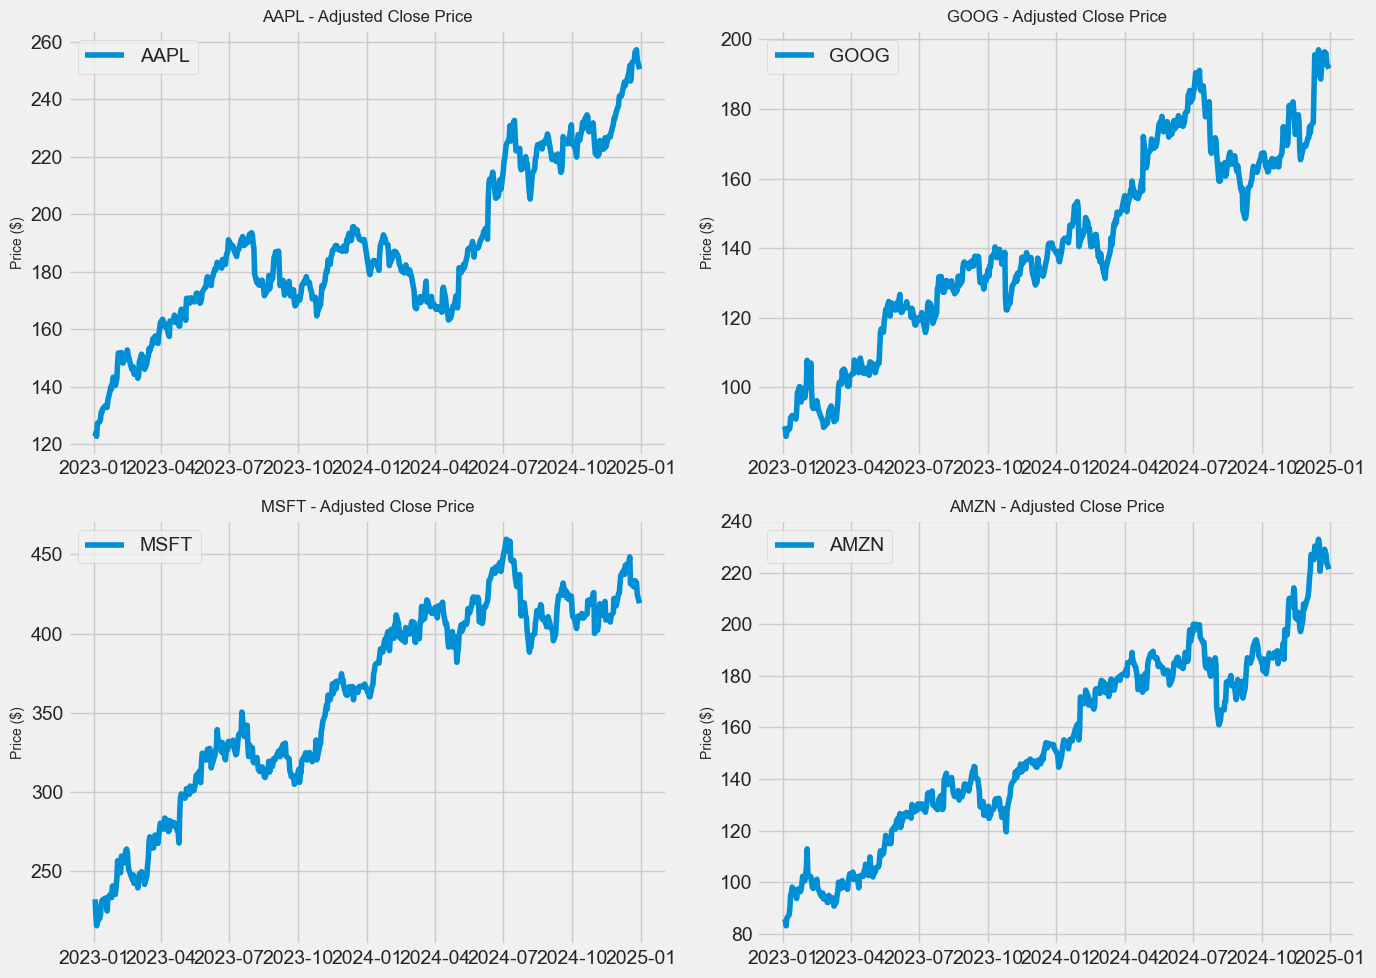

In [15]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import time

# --- Stock list and date range ---
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
start_date = "2023-01-01"
end_date = "2024-12-31"

# --- Create empty dict to store data ---
data_dict = {}

for ticker in tech_list:
    print(f"Downloading data for {ticker} ...")
    try:
        # ✅ Force auto_adjust=False to keep 'Adj Close'
        df = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=False)
        time.sleep(1)  # prevent rate limit
        
        if not df.empty:
            df["Ticker"] = ticker
            data_dict[ticker] = df
            print(f"✅ {ticker} data downloaded successfully.")
        else:
            print(f"⚠️ No data returned for {ticker}.")
    except Exception as e:
        print(f"❌ Failed to download {ticker}: {e}")

# --- Combine all downloaded data ---
if not data_dict:
    print("\n❌ No data downloaded. Try running again after a few minutes (rate limit issue).")
else:
    df_all = pd.concat(data_dict.values())
    print("\n✅ All data combined successfully!")

    # --- Plot Adjusted Close price for each company ---
    plt.figure(figsize=(14, 10))
    plt.subplots_adjust(top=0.9, bottom=0.05)

    for i, ticker in enumerate(tech_list, 1):
        plt.subplot(2, 2, i)
        if ticker in data_dict and "Adj Close" in data_dict[ticker].columns:
            plt.plot(data_dict[ticker].index, data_dict[ticker]["Adj Close"], label=f"{ticker}")
            plt.title(f"{ticker} - Adjusted Close Price", fontsize=12)
            plt.ylabel("Price ($)", fontsize=10)
            plt.grid(True)
            plt.legend()
        else:
            plt.text(0.5, 0.5, f"No Adj Close data for {ticker}", ha="center", va="center")

    plt.tight_layout()
    plt.show()


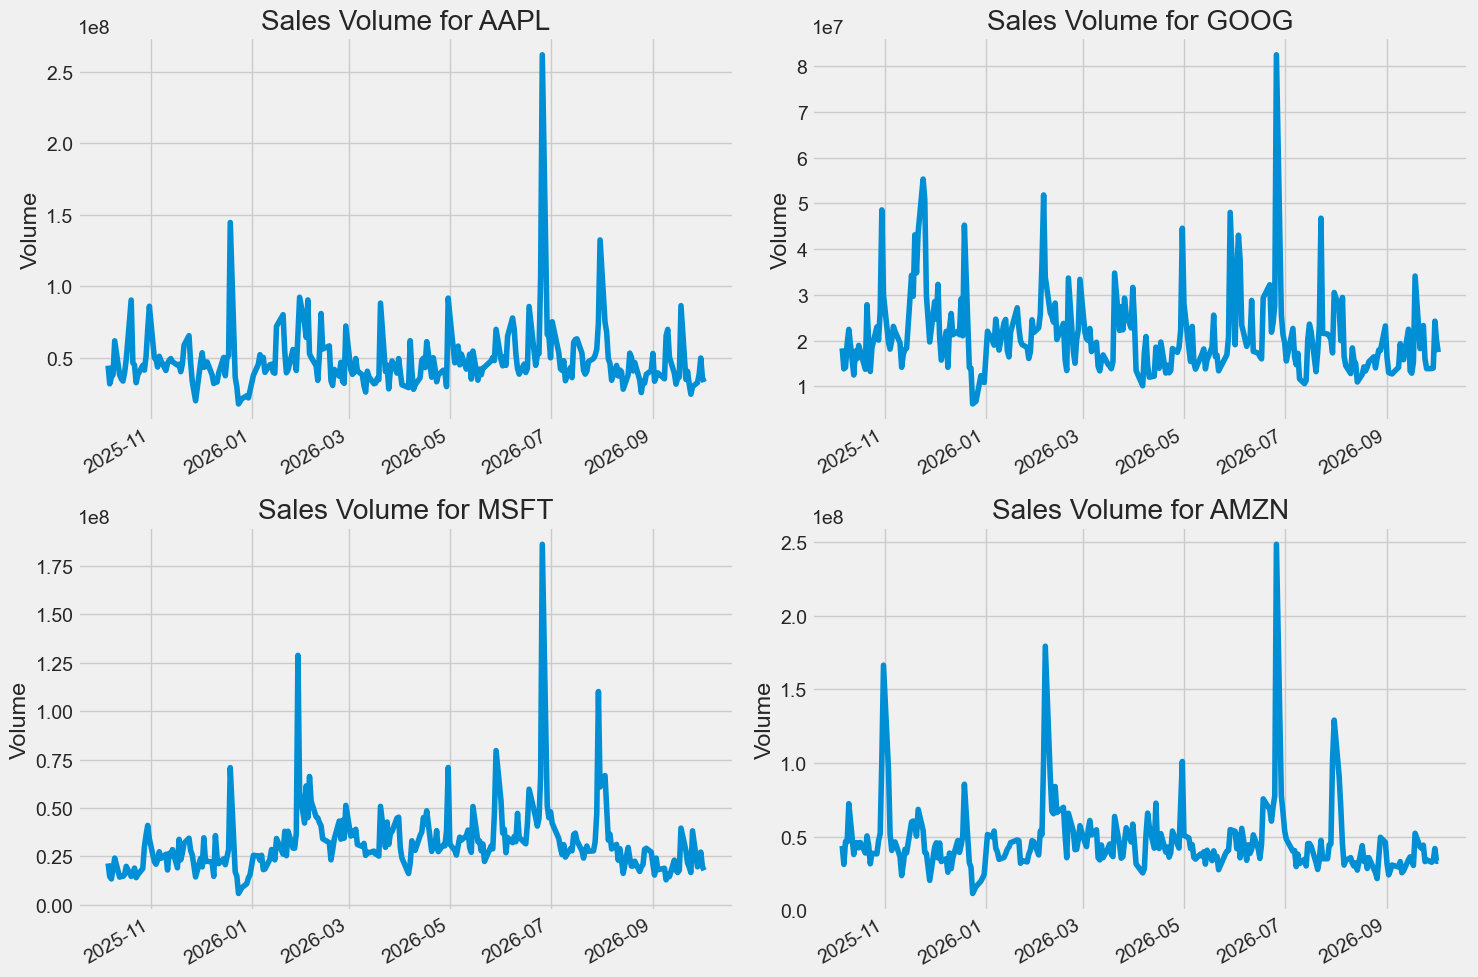

In [16]:
# Now let's plot the total volume of stock being traded each day
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Volume'].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Sales Volume for {tech_list[i - 1]}")
    
plt.tight_layout()

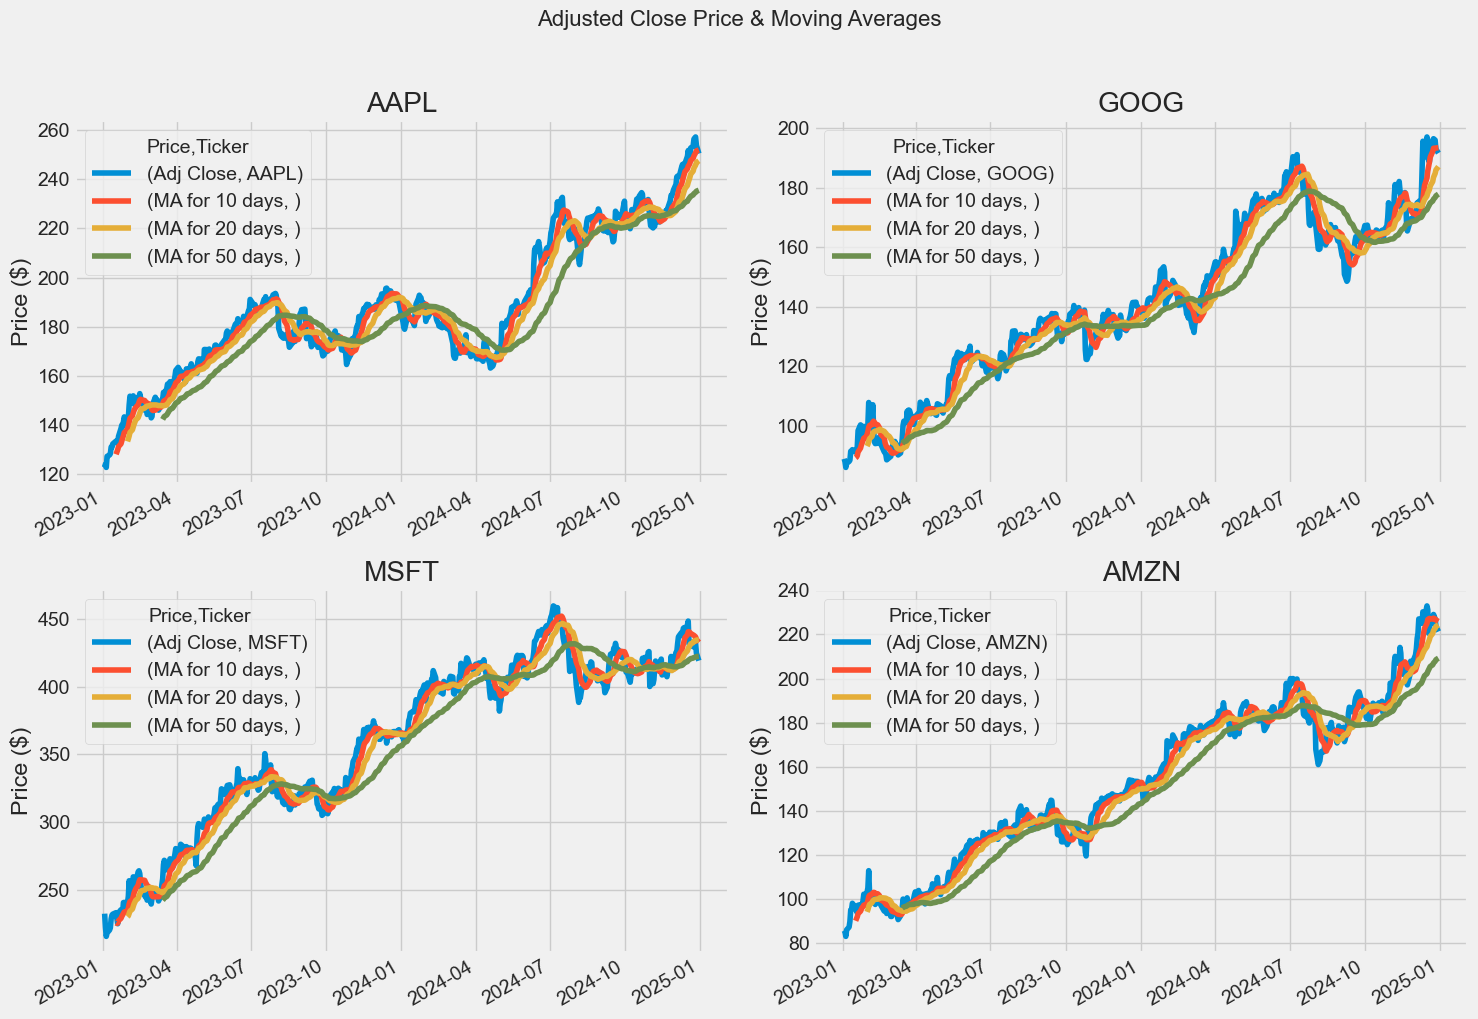

In [17]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Download data ---
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
start_date = '2023-01-01'
end_date = '2024-12-31'

company_data = {}

for ticker in tech_list:
    df = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=False)
    if not df.empty:
        company_data[ticker] = df

# --- Step 2: Compute Moving Averages ---
ma_days = [10, 20, 50]

for ticker, df in company_data.items():
    for ma in ma_days:
        df[f"MA for {ma} days"] = df['Adj Close'].rolling(window=ma).mean()

# --- Step 3: Plot all companies with MAs ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.suptitle("Adjusted Close Price & Moving Averages", fontsize=16, y=1.02)

# Flatten axes for easy indexing
axes = axes.flatten()

for i, ticker in enumerate(tech_list):
    df = company_data.get(ticker)
    if df is not None:
        df[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[i])
        axes[i].set_title(ticker)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Price ($)")
        axes[i].grid(True)

plt.tight_layout()
plt.show()


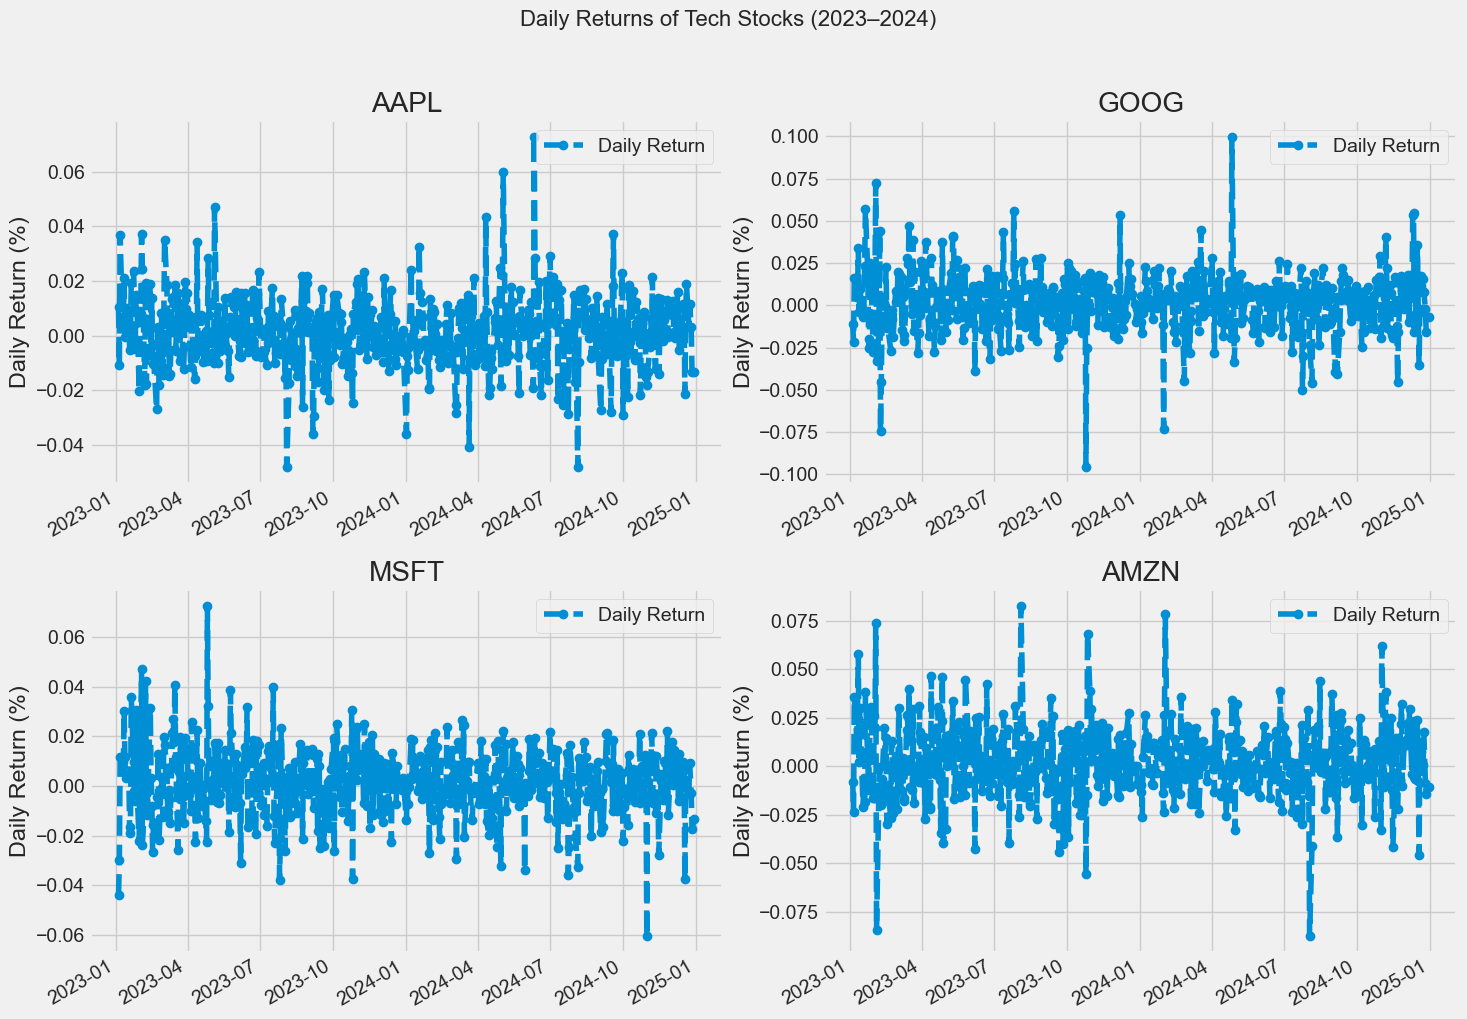

In [18]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Download data ---
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
start_date = '2023-01-01'
end_date = '2024-12-31'

company_data = {}

for ticker in tech_list:
    df = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=False)
    if not df.empty:
        company_data[ticker] = df

# --- Step 2: Calculate Daily Returns ---
for ticker, df in company_data.items():
    df['Daily Return'] = df['Adj Close'].pct_change()

# --- Step 3: Plot Daily Returns ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
fig.suptitle("Daily Returns of Tech Stocks (2023–2024)", fontsize=16, y=1.02)

axes = axes.flatten()

for i, ticker in enumerate(tech_list):
    df = company_data.get(ticker)
    if df is not None:
        df['Daily Return'].plot(ax=axes[i], legend=True, linestyle='--', marker='o')
        axes[i].set_title(ticker)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Daily Return (%)")
        axes[i].grid(True)

plt.tight_layout()
plt.show()


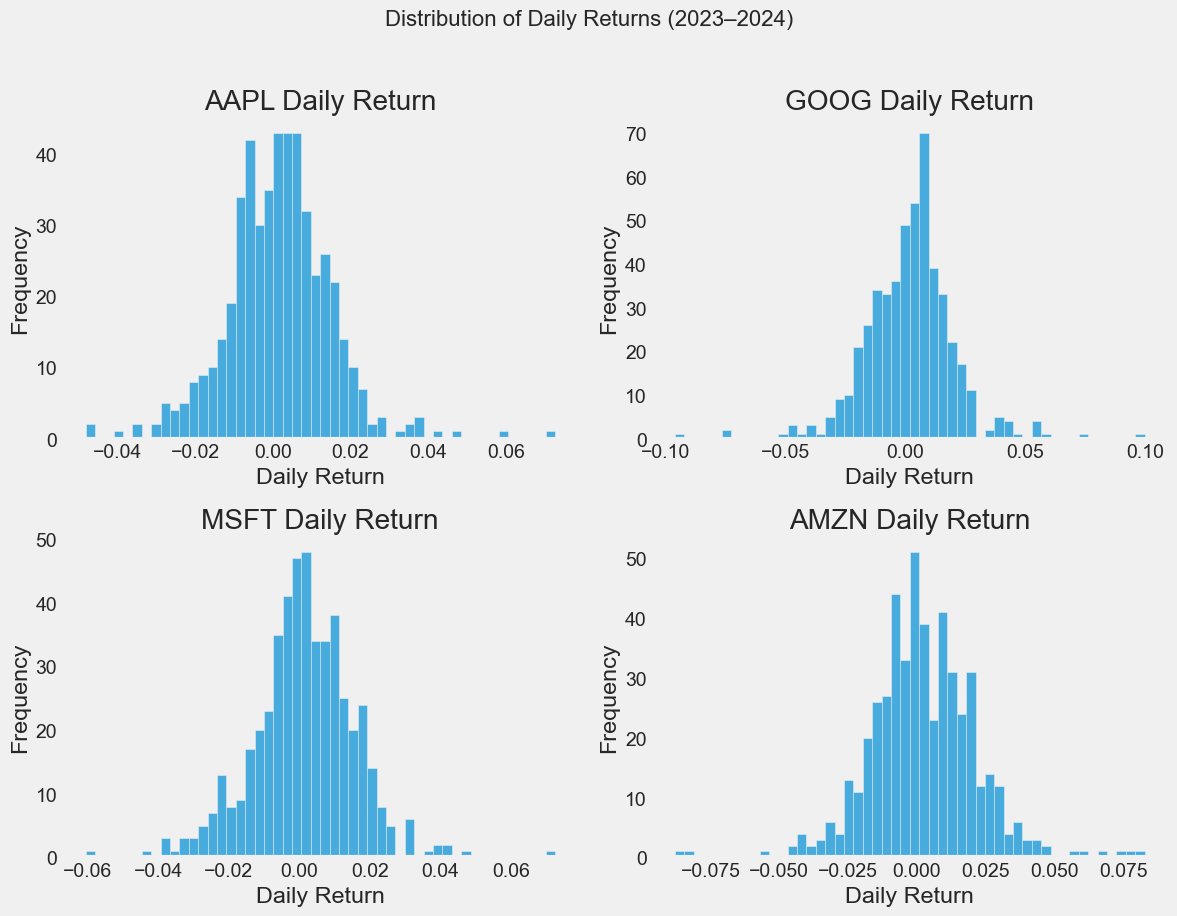

In [19]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Download data ---
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
start_date = '2023-01-01'
end_date = '2024-12-31'

company_data = {}
for ticker in tech_list:
    df = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=False)
    if not df.empty:
        df['Daily Return'] = df['Adj Close'].pct_change()
        company_data[ticker] = df

# --- Step 2: Plot histograms of daily returns ---
plt.figure(figsize=(12, 9))
plt.suptitle("Distribution of Daily Returns (2023–2024)", fontsize=16, y=1.02)

for i, ticker in enumerate(tech_list, 1):
    plt.subplot(2, 2, i)
    df = company_data.get(ticker)
    if df is not None:
        df['Daily Return'].hist(bins=50, alpha=0.7)
        plt.xlabel('Daily Return')
        plt.ylabel('Frequency')
        plt.title(f'{ticker} Daily Return')
        plt.grid(False)

plt.tight_layout()
plt.show()


In [20]:
import yfinance as yf
import pandas as pd

# --- Define stock list and date range ---
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
start = '2023-01-01'
end = '2024-12-31'

# --- Step 1: Download data with auto_adjust=False to keep 'Adj Close' ---
data = yf.download(tech_list, start=start, end=end, group_by='ticker', auto_adjust=False)

# --- Step 2: Create DataFrame of Adjusted Close prices ---
closing_df = pd.DataFrame({ticker: data[ticker]['Adj Close'] for ticker in tech_list})

# --- Step 3: Compute daily percentage returns ---
tech_rets = closing_df.pct_change()

# --- Step 4: Display results ---
print("✅ Adjusted Closing Prices:")
print(closing_df.head())

print("\n✅ Daily Percentage Returns:")
print(tech_rets.head())


[*********************100%***********************]  4 of 4 completed

✅ Adjusted Closing Prices:
                  AAPL       GOOG        MSFT       AMZN
Date                                                    
2023-01-03  122.876740  88.858368  232.510529  85.820000
2023-01-04  124.144112  87.877640  222.339798  85.139999
2023-01-05  122.827614  85.955856  215.750153  83.120003
2023-01-06  127.346939  87.332817  218.292831  86.080002
2023-01-09  127.867615  87.966820  220.418228  87.360001

✅ Daily Percentage Returns:
                AAPL      GOOG      MSFT      AMZN
Date                                              
2023-01-03       NaN       NaN       NaN       NaN
2023-01-04  0.010314 -0.011037 -0.043743 -0.007924
2023-01-05 -0.010605 -0.021869 -0.029638 -0.023726
2023-01-06  0.036794  0.016019  0.011785  0.035611
2023-01-09  0.004089  0.007260  0.009736  0.014870


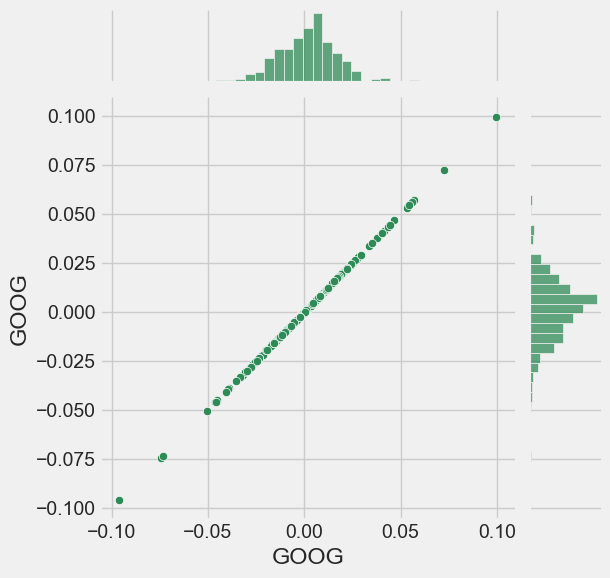

In [21]:
# Comparing Google to itself should show a perfectly linear relationship
sns.jointplot(x='GOOG', y='GOOG', data=tech_rets, kind='scatter', color='seagreen')

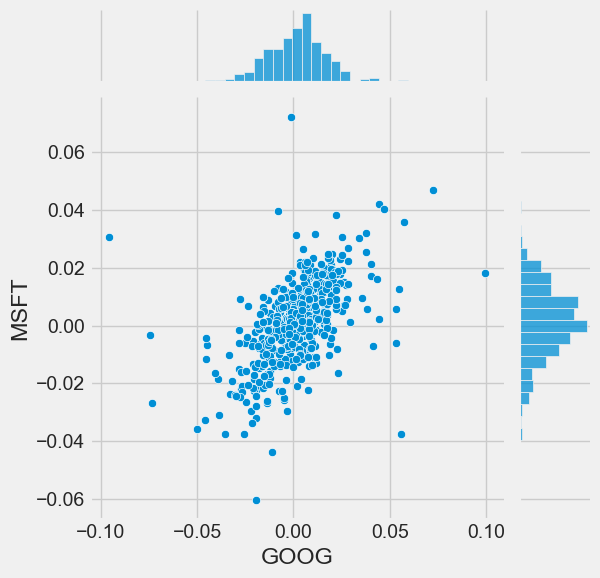

In [22]:
# We'll use joinplot to compare the daily returns of Google and Microsoft
sns.jointplot(x='GOOG', y='MSFT', data=tech_rets, kind='scatter')

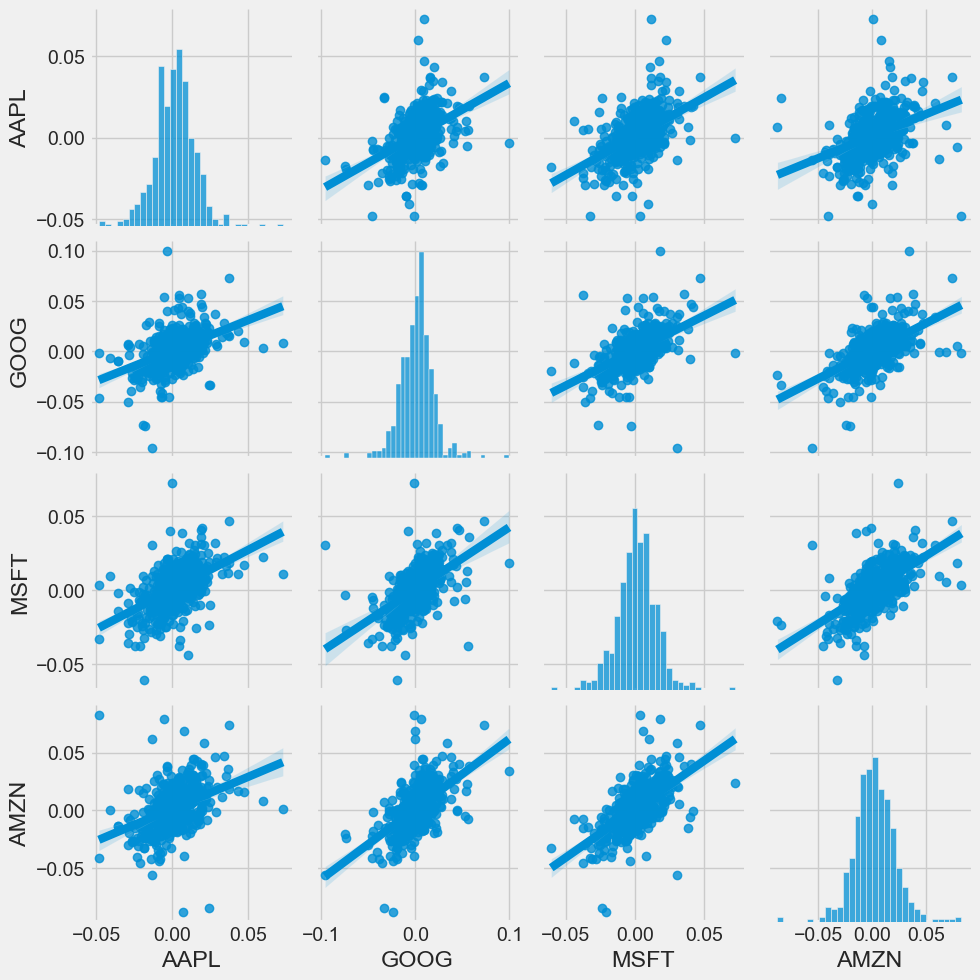

In [23]:
    # We can simply call pairplot on our DataFrame for an automatic visual analysis 
# of all the comparisons

sns.pairplot(tech_rets, kind='reg')

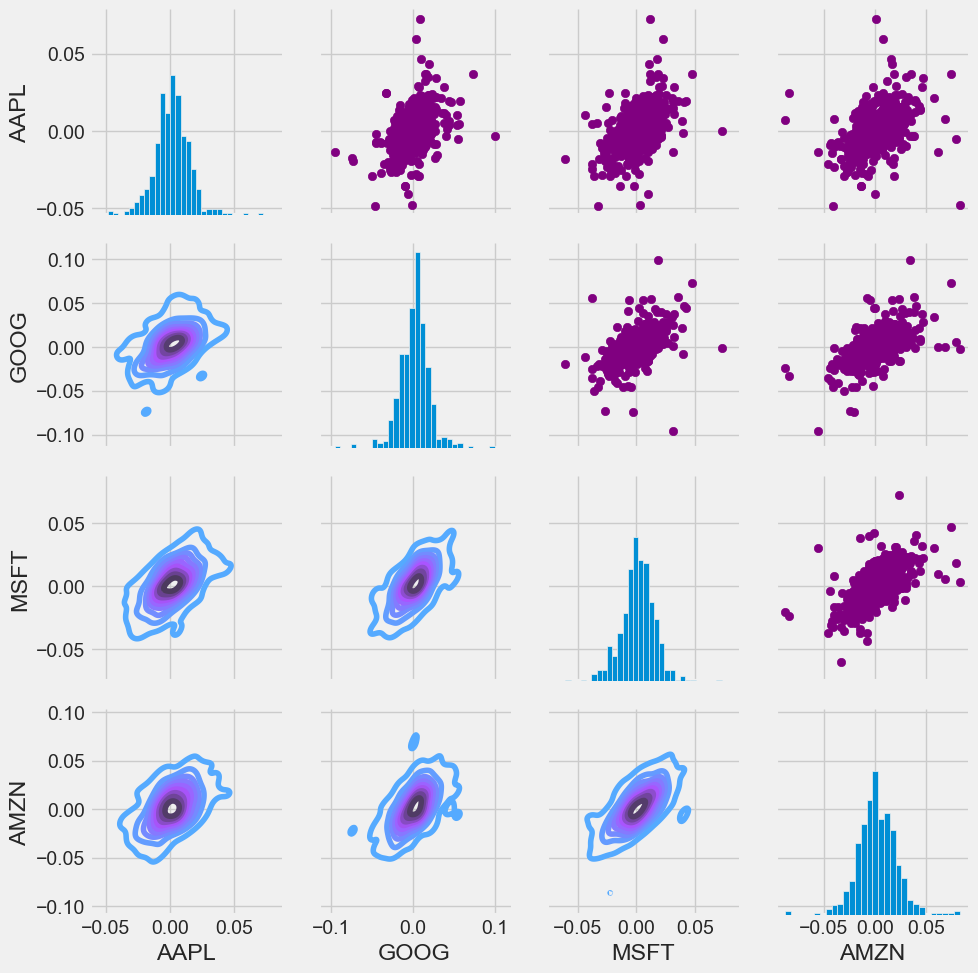

In [24]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
return_fig = sns.PairGrid(tech_rets.dropna())

# Using map_upper we can specify what the upper triangle will look like.
return_fig.map_upper(plt.scatter, color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) 
# or the color map (BluePurple)
return_fig.map_lower(sns.kdeplot, cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
return_fig.map_diag(plt.hist, bins=30)

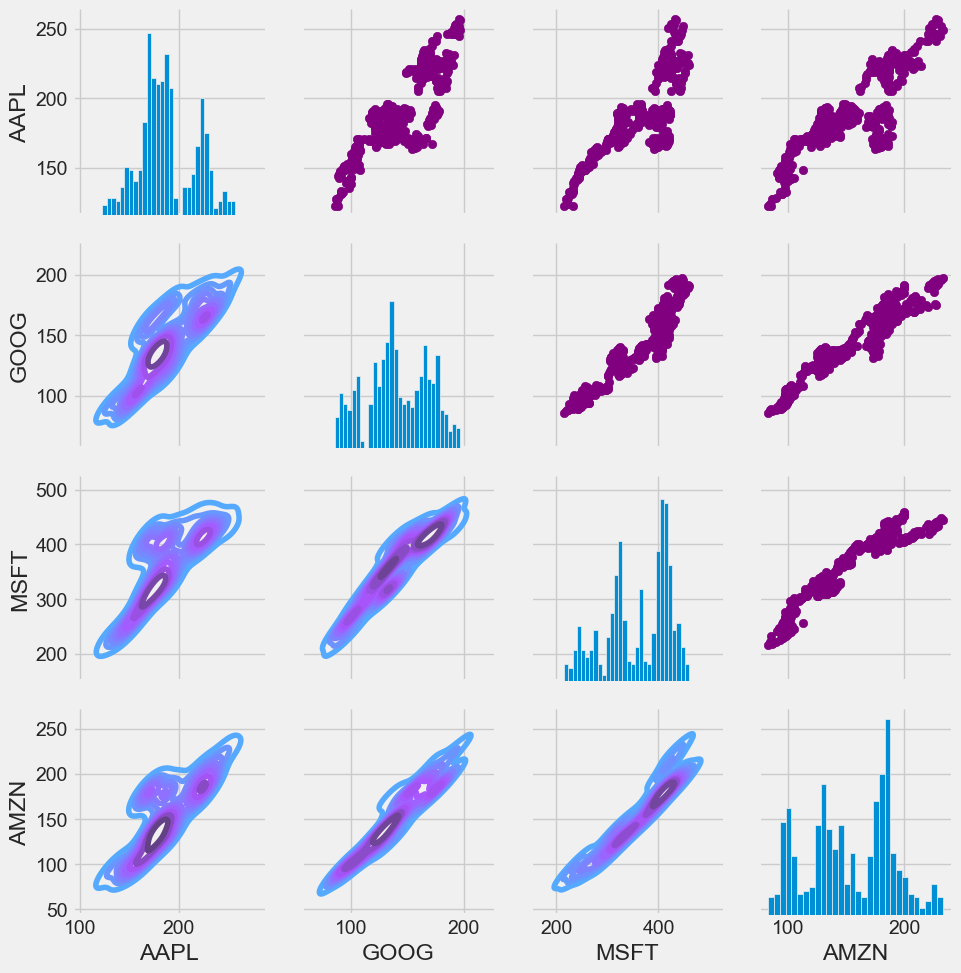

In [25]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
returns_fig = sns.PairGrid(closing_df)

# Using map_upper we can specify what the upper triangle will look like.
returns_fig.map_upper(plt.scatter,color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) or the color map (BluePurple)
returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
returns_fig.map_diag(plt.hist,bins=30)

Text(0.5, 1.0, 'Correlation of stock closing price')

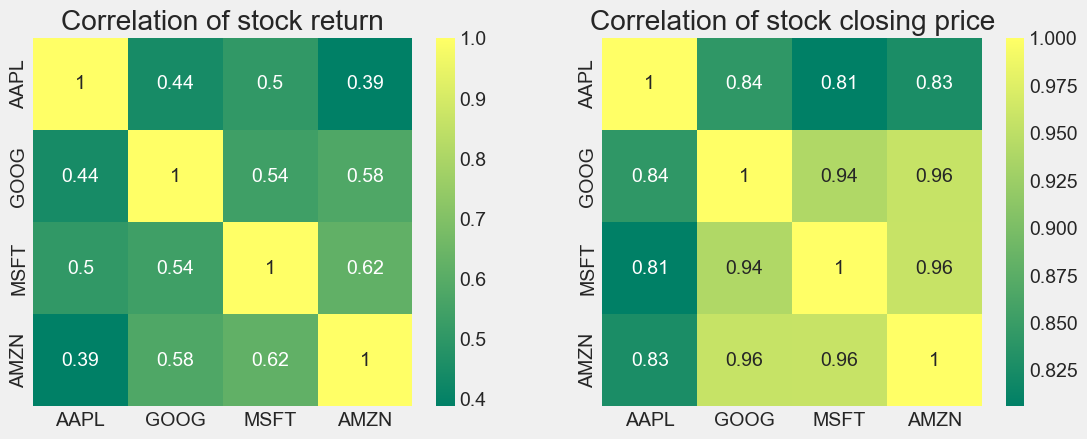

In [26]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')

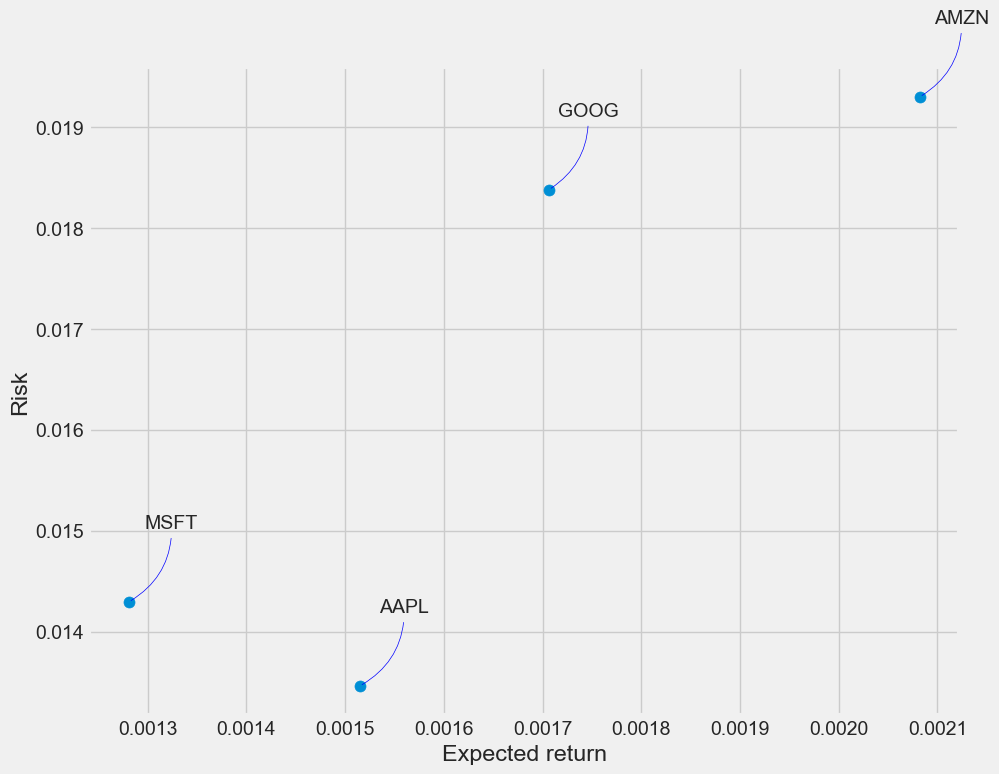

In [27]:
rets = tech_rets.dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom', 
                 arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))


In [28]:
import yfinance as yf
import pandas as pd
from datetime import datetime

# --- Fetch Apple (AAPL) stock data directly using yfinance ---
df = yf.download('AAPL', start='2012-01-01', end=datetime.now())

# --- Display the data ---
print(df.head())


[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2012-01-03  12.299739  12.337725  12.233041  12.245005  302220800
2012-01-04  12.365836  12.402925  12.241412  12.262947  260022000
2012-01-05  12.503121  12.518674  12.342805  12.411000  271269600
2012-01-06  12.633828  12.644296  12.538716  12.555166  318292800
2012-01-09  12.613789  12.793845  12.602423  12.726548  394024400


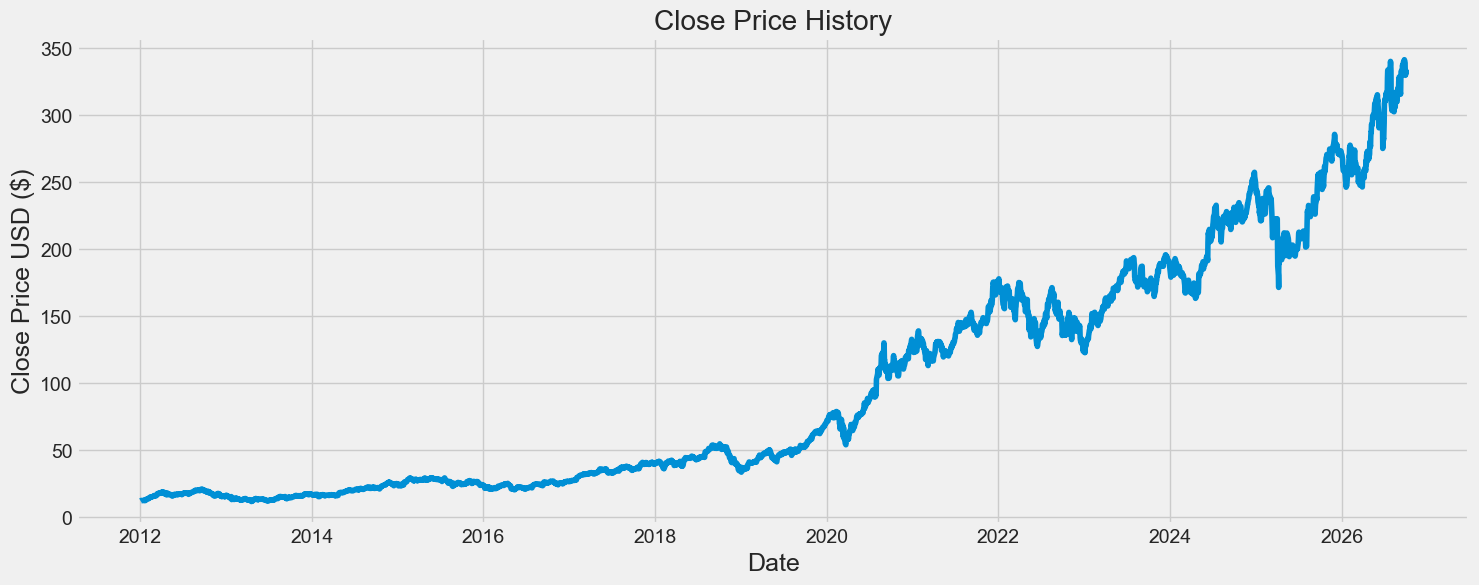

In [29]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [30]:
# Create a new dataframe with only the 'Close column 
data = df.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

3524

In [31]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

# --- Step 1: Download stock data ---
df = yf.download('AAPL', start='2012-01-01', end=datetime.now())

# --- Step 2: Select the 'Close' price column as dataset ---
dataset = df['Close'].values  # get only closing prices
dataset = dataset.reshape(-1, 1)  # reshape for scaler (2D input required)

# --- Step 3: Scale data between 0 and 1 ---
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# --- Step 4: Display results ---
print("Scaled Data (first 10 values):")
print(scaled_data[:10])


[*********************100%***********************]  1 of 1 completed

Scaled Data (first 10 values):
[[0.0013569 ]
 [0.00155768]
 [0.00197468]
 [0.00237171]
 [0.00231084]
 [0.00244801]
 [0.00238532]
 [0.00227994]
 [0.0021364 ]
 [0.00258066]]


In [32]:
# Create the training data set 
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()
        
# Convert the x_train and y_train to numpy arrays 
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.0013569 , 0.00155768, 0.00197468, 0.00237171, 0.00231084,
       0.00244801, 0.00238532, 0.00227994, 0.0021364 , 0.00258066,
       0.00298132, 0.00285775, 0.00218092, 0.00282688, 0.0021909 ,
       0.00457574, 0.00439132, 0.00463208, 0.00515264, 0.0054679 ,
       0.00544155, 0.00534435, 0.00575863, 0.00614838, 0.00658991,
       0.00730309, 0.00880122, 0.00882393, 0.00965793, 0.01028118,
       0.00921005, 0.00962251, 0.00961431, 0.01077087, 0.01060643,
       0.0109108 , 0.01145768, 0.01176204, 0.01263878, 0.01327744,
       0.01346184, 0.01352636, 0.01243433, 0.01217087, 0.01220995,
       0.01323655, 0.01352546, 0.01414596, 0.01560868, 0.01756016,
       0.01719491, 0.01719582, 0.01860675, 0.01904829, 0.01873394,
       0.01844685, 0.01814794, 0.01914094, 0.01982231, 0.02010761])]
[np.float64(0.01940263265998575)]

[array([0.0013569 , 0.00155768, 0.00197468, 0.00237171, 0.00231084,
       0.00244801, 0.00238532, 0.00227994, 0.0021364 , 0.00258066,
       0.00298132, 0.00

In [33]:
# --- Import libraries ---
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
from datetime import datetime
import matplotlib.pyplot as plt

# --- Step 1: Download Apple stock data ---
df = yf.download('AAPL', start='2012-01-01', end=datetime.now(), auto_adjust=False)

# --- Step 2: Choose correct column dynamically ---
if 'Adj Close' in df.columns:
    data = df[['Adj Close']]
elif 'Close' in df.columns:
    data = df[['Close']]
else:
    raise ValueError("No 'Adj Close' or 'Close' column found in downloaded data!")

# --- Step 3: Convert to numpy array ---
dataset = data.values

# --- Step 4: Define training data length ---
training_data_len = int(np.ceil(len(dataset) * 0.8))

# --- Step 5: Scale the data ---
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# --- Step 6: Create training dataset ---
train_data = scaled_data[0:training_data_len, :]

x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

# Convert to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# --- Step 7: Reshape data for LSTM ---
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# --- Step 8: Build the LSTM model ---
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# --- Step 9: Compile the model ---
model.compile(optimizer='adam', loss='mean_squared_error')

# --- Step 10: Train the model ---
model.fit(x_train, y_train, batch_size=1, epochs=1)

# --- Step 11: Show summary ---
model.summary()


[*********************100%***********************]  1 of 1 completed
C:\Python314\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2908/2908 ━━━━━━━━━━━━━━━━━━━━ 33s 11ms/step - loss: 4.6383e-04


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [34]:
 #Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002 
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    
# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


np.float64(9.015269137589257)

Epoch 1/10


C:\Python314\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0022
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.3222e-04
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.3181e-04
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.2070e-04
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.1211e-04
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.0500e-04
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 1.0124e-04
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 9.8178e-05
Epoch 9/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 9.2354e-05
Epoch 10/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 8.6411e-05
✅ LSTM model saved successfully!
✅ File: stock_lstm_model.keras
✅ Scaler saved successfully!
✅ File: stock_scaler.pkl
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Price        Adj Close Predictions
Ticker            AAPL            
Date                              
2026-09-21  338.980011  313.547424
2026-09-22  339.

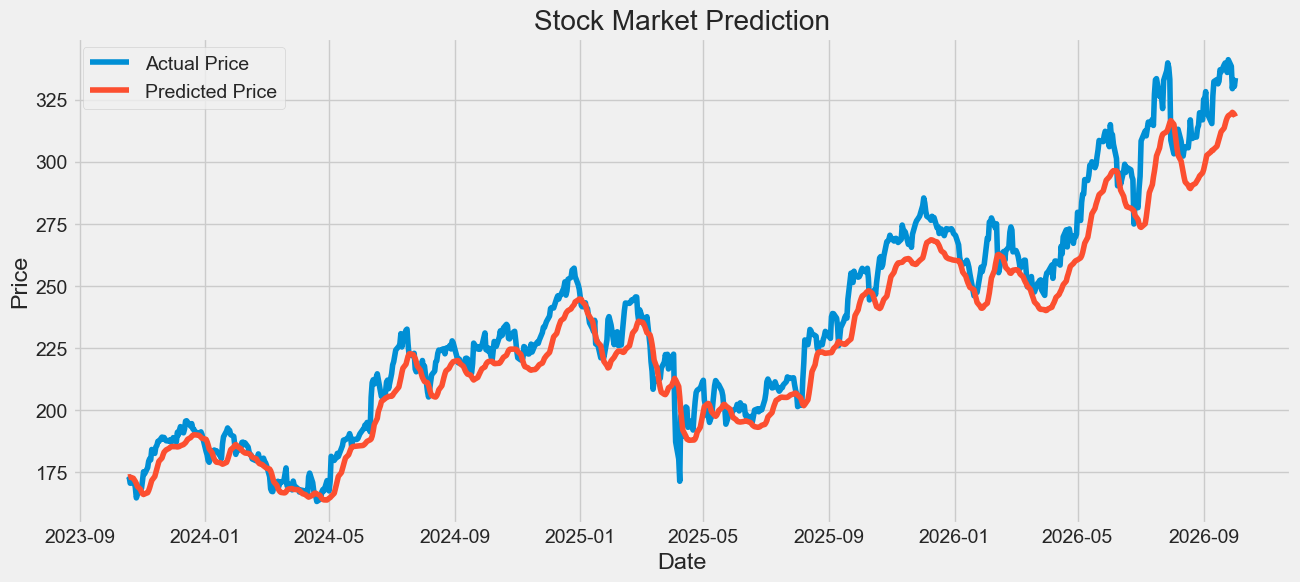

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
import joblib

data = data.copy()

if "Adj Close" in data.columns:
    price_col = "Adj Close"
else:
    price_col = "Close"

prices = data[price_col].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(prices)

training_data_len = int(len(scaled_data) * 0.8)

train_data = scaled_data[:training_data_len]

X_train = []
y_train = []

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

X_train = np.reshape(
    X_train,
    (X_train.shape[0], X_train.shape[1], 1)
)

test_data = scaled_data[training_data_len - 60:]

X_test = []
y_test = []

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    y_test.append(test_data[i, 0])

X_test = np.array(X_test)
y_test = np.array(y_test)

X_test = np.reshape(
    X_test,
    (X_test.shape[0], X_test.shape[1], 1)
)

model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(
    LSTM(
        50,
        return_sequences=False
    )
)

model.add(Dense(25))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# -----------------------------------
# Train the LSTM model
# -----------------------------------

model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=10,
    verbose=1
)

# -----------------------------------
# Save the trained LSTM model
# -----------------------------------

model.save("stock_lstm_model.keras")

# -----------------------------------
# Save the scaler
# -----------------------------------

joblib.dump(
    scaler,
    "stock_scaler.pkl"
)

print("===================================")
print("✅ LSTM model saved successfully!")
print("✅ File: stock_lstm_model.keras")
print("✅ Scaler saved successfully!")
print("✅ File: stock_scaler.pkl")
print("===================================")

# -----------------------------------
# Make predictions
# -----------------------------------

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

# -----------------------------------
# Create validation dataframe
# -----------------------------------

valid = data.iloc[training_data_len:].copy()

valid["Predictions"] = predictions.flatten()

print(
    valid[
        [price_col, "Predictions"]
    ].tail(10)
)

# -----------------------------------
# Plot actual vs predicted
# -----------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    valid.index,
    valid[price_col],
    label="Actual Price"
)

plt.plot(
    valid.index,
    valid["Predictions"],
    label="Predicted Price"
)

plt.title("Stock Market Prediction")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

In [34]:
# Show the valid and predicted prices
valid

Price,Adj Close,Predictions
Ticker,AAPL,
Date,,
2023-10-18,173.493484,177.465179
2023-10-19,173.118530,177.532150
2023-10-20,170.572983,177.377045
2023-10-23,170.691406,176.893295
2023-10-24,171.125473,176.251755
...,...,...
2026-09-28,338.399994,322.043488
2026-09-29,329.399994,322.548889
